Found 4 CSV files:
 - SoC-Rel.csv
 - SoC_full.csv
 - SoC-Lesioned.csv
 - SoC-Gen.csv
Unique SoC-Gen model configurations:
 - theta=(99,1), gen=0.1, true_prior=0.02
 - theta=(99,1), gen=0.3, true_prior=0.02
 - theta=(99,1), gen=0.5, true_prior=0.02
 - theta=(99,1), gen=0.7, true_prior=0.02
 - theta=(99,1), gen=0.9, true_prior=0.02


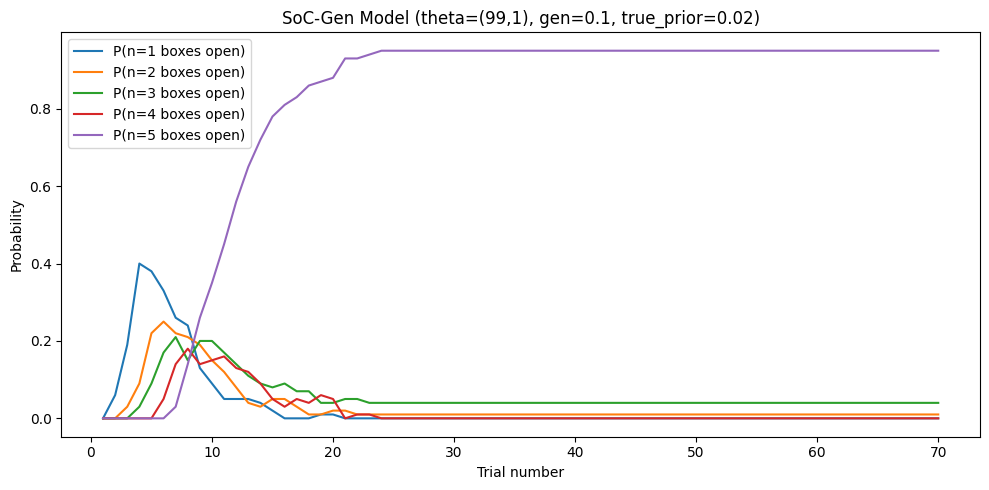

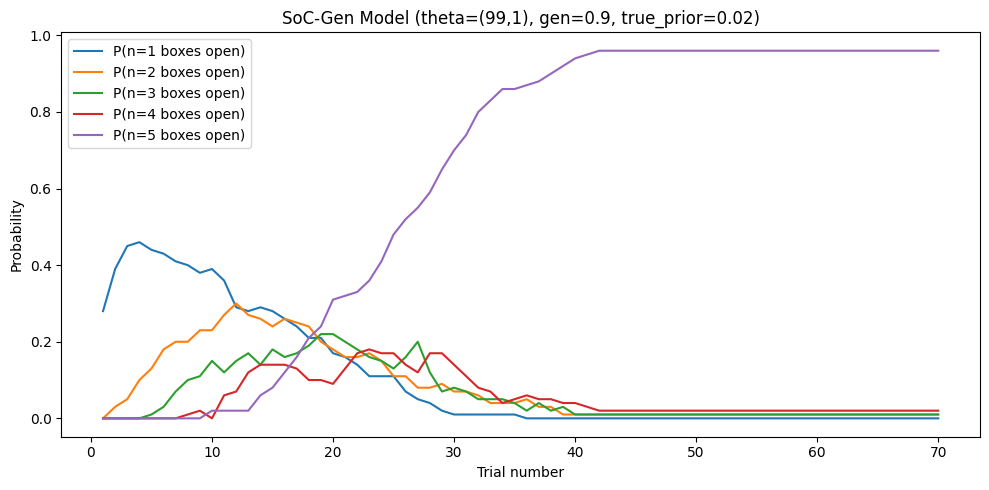

In [15]:
# load all csvs f
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_files = glob.glob(os.path.join(os.getcwd(), "model_runs/*.csv"))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f" - {os.path.basename(f)}")

# the loaded csvs contain the P(n=x boxes open) for different model configurations

# print out all unique model configurations for SoC-Gen
# model configuration is given by the values of theta, gen, true_prior
# Note: theta is a tuple-string like "(99,1)" — multiple configs live in the same file
unique_models = set()

for f in csv_files:
    if "SoC-Gen" in f:
        df = pd.read_csv(f)
        for _, row in df[['theta', 'gen', 'true_prior']].drop_duplicates().iterrows():
            unique_models.add((row['theta'], float(row['gen']), float(row['true_prior'])))

print("Unique SoC-Gen model configurations:")
for m in sorted(unique_models, key=lambda x: (x[0], x[1])):
    print(f" - theta={m[0]}, gen={m[1]}, true_prior={m[2]}")


# filter data for the first model and plot it
target_model = ("(99,1)", 0.1, 0.02)

for f in csv_files:
    if "SoC-Gen" in f:
        df = pd.read_csv(f)
        mask = (
            (df['theta'] == target_model[0]) &
            (df['gen'] == target_model[1]) &
            (df['true_prior'] == target_model[2])
        )
        df_target = df[mask]
        if not df_target.empty:
            break

# plot the P(n=x boxes open) across trials for x=1..5 for this model
plt.figure(figsize=(10, 5))
for x in range(1, 6):
    plt.plot(df_target['trialNo'], df_target[f'P(n={x} boxes open)'], label=f'P(n={x} boxes open)')
plt.xlabel('Trial number')
plt.ylabel('Probability')
plt.title(f"SoC-Gen Model (theta={target_model[0]}, gen={target_model[1]}, true_prior={target_model[2]})")
plt.legend()
plt.tight_layout()
plt.show()


# now show theta=(99,1), gen=0.9 below
target_model = ("(99,1)", 0.9, 0.02)

for f in csv_files:
    if "SoC-Gen" in f:
        df = pd.read_csv(f)
        mask = (
            (df['theta'] == target_model[0]) &
            (df['gen'] == target_model[1]) &
            (df['true_prior'] == target_model[2])
        )
        df_target = df[mask]
        if not df_target.empty:
            break

# plot the P(n=x boxes open) across trials for x=1..5 for this model
plt.figure(figsize=(10, 5))
for x in range(1, 6):
    plt.plot(df_target['trialNo'], df_target[f'P(n={x} boxes open)'], label=f'P(n={x} boxes open)')
plt.xlabel('Trial number')
plt.ylabel('Probability')
plt.title(f"SoC-Gen Model (theta={target_model[0]}, gen={target_model[1]}, true_prior={target_model[2]})")
plt.legend()
plt.tight_layout()
plt.show()



Sanity check --  looks reasonable, it takes longer for the second configuration to open boxes.


In [16]:

# first, we load the actual chidl data from 
f = os.path.normpath(os.path.join(os.getcwd(), "..", "child_data", "trials.csv"))

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(f)

# drop columns with time in name
df = df.drop(columns=[col for col in df.columns if 'time' in col.lower()])

# print table head
print(df.head(n=20))


# there are columns: ID,  Order,   Box, Key,  Worked, Error
# ID - child id
# Order - is attempt number
# box - string id of box
# key - string id of key
# Worked - 1 if the key worked, 0 if not

# get all boxes and keys
boxes = df['Box'].unique()
keys = df['Key'].unique()

# identify all children who opened all boxes
children = df['ID'].unique()
successful_children = []
for child in children:
    child_data = df[df['ID'] == child]
    opened_boxes = child_data[child_data['Worked'] == 1]['Box'].unique()
    if set(opened_boxes) == set(boxes):
        successful_children.append(child)

# numner of successful children
print("Number of successful children:", len(successful_children))


      ID  Order     Box      Key  Worked  Error  ColorMatch  NumMatch  \
0   D001      1     red      red       0      1           1         1   
1   D001      2     red      red       1      0           1         1   
2   D001      3    pink     pink       0      0           1         0   
3   D001      4    pink    grey2       1      0           0         1   
4   D001      5   white  orange4       1      0           0         1   
5   D001      6  purple   green3       1      0           0         1   
6   D001      7    blue     blue       0      0           1         0   
7   D001      8    blue     blue       0      0           1         0   
8   D001      9    blue    cloud       0      0           0         0   
9   D001     10    blue    cloud       0      0           0         0   
10  D001     11    blue    cloud       0      0           0         0   
11  D001     12    blue  yellow5       0      1           0         1   
12  D001     13    blue  yellow5       0      1    

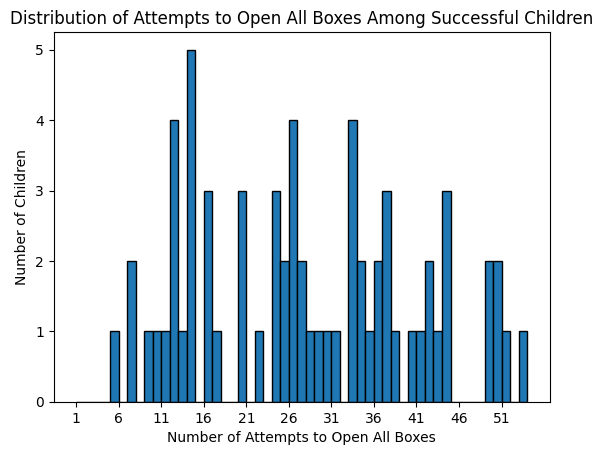

Mean number of attempts to open all boxes: 27.636363636363637
Standard deviation of attempts to open all boxes: 12.868373685991328


In [17]:
# now compute the number of attempts it took for each successful child to open all boxes
attempts_to_success = []
for child in successful_children:
    child_data = df[df['ID'] == child]
    attempts = 0
    opened_boxes = set()
    for index, row in child_data.iterrows():
        attempts += 1
        if row['Worked'] == 1:
            opened_boxes.add(row['Box'])
        if opened_boxes == set(boxes):
            break
    attempts_to_success.append(attempts)

# plot histogram of attempts to success
# ticks every 5 trials

plt.hist(attempts_to_success, bins=range(1, max(attempts_to_success)+1), edgecolor='black')
plt.xlabel('Number of Attempts to Open All Boxes')
plt.ylabel('Number of Children')
plt.title('Distribution of Attempts to Open All Boxes Among Successful Children')
plt.xticks(range(1, max(attempts_to_success)+1, 5))
plt.show()

# the count of attempst is in the variable attempts_to_success

# mean
mean_attempts = sum(attempts_to_success) / len(attempts_to_success)
print("Mean number of attempts to open all boxes:", mean_attempts)
sd = (sum((x - mean_attempts) ** 2 for x in attempts_to_success) / len(attempts_to_success)) ** 0.5
print("Standard deviation of attempts to open all boxes:", sd)

SoC-Gen.csv has the flowing unique SoC-Gen model configurations:
 - theta=(99,1), gen=0.1, true_prior=0.02
 - theta=(99,1), gen=0.3, true_prior=0.02
 - theta=(99,1), gen=0.5, true_prior=0.02
 - theta=(99,1), gen=0.7, true_prior=0.02
 - theta=(99,1), gen=0.9, true_prior=0.02

 we will use child data to compute the posterior log likelihood that each of these models explains behaviour

 to do this, we track the probability of the number of boxes n_i opened on trial i under each model



In [22]:
import pandas as pd
import numpy as np
import os

# ── 1. Load SoC-Gen probability tables ───────────────────────────────────────
# Each row gives P(n=k boxes open | trialNo, model_variant).
# Model variants differ only in 'gen'; theta and true_prior are fixed.

soc_gen_path = os.path.join(os.getcwd(), "model_runs", "SoC-Gen.csv")
df_soc = pd.read_csv(soc_gen_path)

prob_cols = [f'P(n={k} boxes open)' for k in range(6)]  # k = 0..5
gen_values = sorted(df_soc['gen'].unique())              # [0.1, 0.3, 0.5, 0.7, 0.9]
max_model_trial = int(df_soc['trialNo'].max())           # 70

# Build one DataFrame per model variant, indexed by trialNo for fast lookup.
# model_tables[gen_val].loc[t, 'P(n=k boxes open)'] = P(n=k | trial t, gen=gen_val)
model_tables = {
    gen_val: df_soc[df_soc['gen'] == gen_val].set_index('trialNo')[prob_cols]
    for gen_val in gen_values
}

# ── 2. Compute cumulative boxes-opened sequence for every child ───────────────
# For child c on attempt i (sorted by Order), n_i = number of distinct boxes
# opened so far (cumulative unique Worked==1 boxes).
# This is the observed state that we score against the model's distribution.

child_sequences = {}  # {child_id: [(trial_no, n_boxes_opened), ...]}

for child in children:
    child_data = df[df['ID'] == child].sort_values('Order')
    opened = set()
    sequence = []
    for _, row in child_data.iterrows():
        if row['Worked'] == 1:
            opened.add(row['Box'])
        sequence.append((int(row['Order']), len(opened)))
    child_sequences[child] = sequence

# ── 3. Compute log likelihood for each child x model variant ─────────────────
# Log likelihood = sum_i  log P(n = n_i | trial i, model)
# Trials beyond the model table (>70) are skipped.
# A probability floor (EPS) prevents log(0) for zero-probability cells.

EPS = 1e-10

records = []
for child in children:
    row = {'child': child}
    for gen_val in gen_values:
        table = model_tables[gen_val]
        log_lik = 0.0
        for trial_no, n_boxes in child_sequences[child]:
            if trial_no > max_model_trial:
                continue  # model table only covers trials 1-70
            p = float(table.loc[trial_no, f'P(n={n_boxes} boxes open)'])
            log_lik += np.log(max(p, EPS))
        row[f'gen={gen_val}'] = round(log_lik, 3)
    records.append(row)

results_df = pd.DataFrame(records)

# ── 4. Add best-fit model column ──────────────────────────────────────────────
ll_cols = [f'gen={g}' for g in gen_values]
results_df['best_gen'] = results_df[ll_cols].idxmax(axis=1).str.replace('gen=', '')

print(results_df.to_string(index=False))


child   gen=0.1   gen=0.3   gen=0.5   gen=0.7   gen=0.9 best_gen
 D001   -26.151   -23.075   -27.646   -35.841   -96.977      0.3
 D002  -113.370  -188.312   -80.727   -96.719   -94.666      0.5
 D003   -81.484  -138.486   -66.652   -59.899   -59.742      0.9
 D004  -429.864  -537.286  -431.773  -326.310  -112.543      0.9
 D005  -191.639   -54.864   -40.000   -36.027   -39.253      0.7
 D006   -24.849   -24.252   -21.628   -23.647   -26.505      0.5
 D007  -416.858  -302.723   -95.888  -185.651   -73.350      0.9
 D008  -312.666  -259.990   -90.461   -99.299   -65.376      0.9
 D009  -164.872  -556.726  -375.458  -465.132  -163.091      0.9
 D010  -138.049  -154.981   -61.904   -61.784   -59.423      0.9
 D011  -293.258  -517.187  -352.771  -434.608  -119.815      0.9
 D012  -119.337  -185.876   -79.924   -69.169   -54.206      0.9
 D013   -18.421   -16.295   -13.732   -15.516   -17.447      0.5
 D014  -249.104  -229.976  -236.194   -83.307   -59.417      0.9
 D015 -1221.455 -1106.207


Best-fit model counts across children:
best_gen
0.1     1
0.3     9
0.5    16
0.7    10
0.9    64
Name: count, dtype: int64

Mean Negative Log-Likelihood by gen value:
  gen=0.1: 233.62 ± 42.48
  gen=0.3: 240.28 ± 51.81
  gen=0.5: 185.66 ± 49.61
  gen=0.7: 151.48 ± 37.86
  gen=0.9: 98.48 ± 29.12


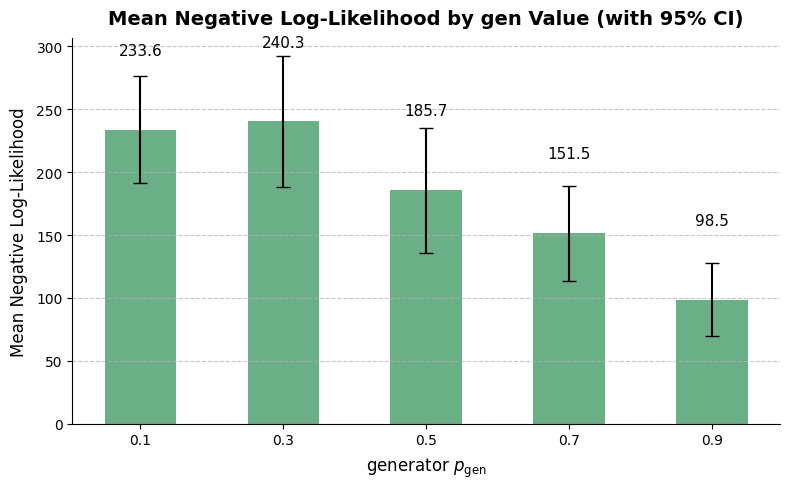

In [23]:
# now we count how often each gen value is the best fit across all children
best_fit_counts = results_df['best_gen'].value_counts().sort_index()
print("\nBest-fit model counts across children:")
print(best_fit_counts)

# compute mean *negative* log-likelihood for each gen with 95% CI
import matplotlib.pyplot as plt

nll_df = -results_df[ll_cols]   # flip sign: lower NLL = better fit

gen_means = nll_df.mean()
gen_sems  = nll_df.sem()
gen_cis   = 1.96 * gen_sems     # 95% CI

# print the values
print("\nMean Negative Log-Likelihood by gen value:")
for g, m, ci in zip(gen_values, gen_means, gen_cis):
    print(f"  gen={g}: {m:.2f} ± {ci:.2f}")

bar_width = 0.1                  # thinner bars so they don't overlap

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    gen_values, gen_means,
    width=bar_width,
    yerr=gen_cis, capsize=5,
    color='#4A9E6B', alpha=0.82
)

# label each bar with its mean NLL value
for bar, mean_val in zip(bars, gen_means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(gen_cis) * 1.1,
        f'{mean_val:.1f}',
        ha='center', va='bottom', fontsize=11
    )

ax.set_xlabel(r'generator $p_{\mathrm{gen}}$', fontsize=12, labelpad=6)
ax.set_ylabel('Mean Negative Log-Likelihood', fontsize=12, labelpad=6)
ax.set_title('Mean Negative Log-Likelihood by gen Value (with 95% CI)',
             fontsize=14, fontweight='bold', pad=10)
ax.set_xticks(gen_values)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


The best fitting model is gen 0.9, mean log likeihood is 98.48

Best-fit SoC-Rel model counts across children:
best_theta
(1,1)    48
(2,1)    12
(3,1)    24
(5,1)     9
(9,1)     7
Name: count, dtype: int64

Mean Negative Log-Likelihood by theta value:
  theta=(1,1): 158.80 ± 18.43
  theta=(2,1): 200.01 ± 26.38
  theta=(3,1): 253.96 ± 41.60
  theta=(5,1): 244.81 ± 40.73
  theta=(9,1): 322.91 ± 54.62
  theta=(19,1): 347.83 ± 53.69


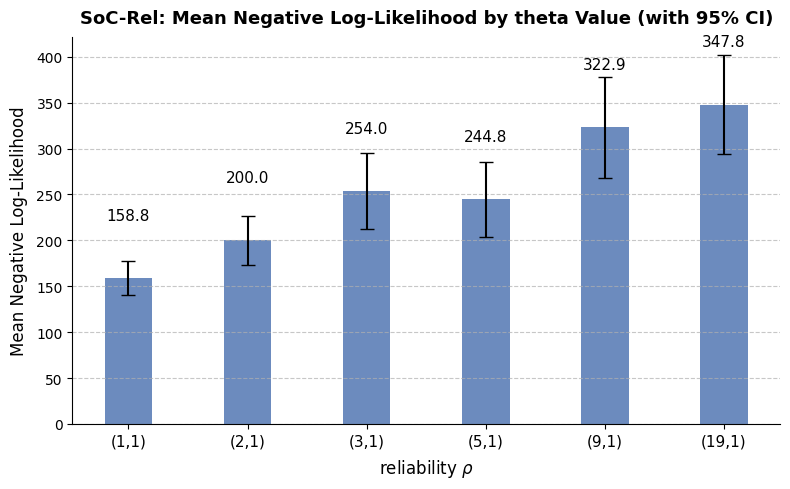

In [24]:
# ── Fit SoC-Rel to each child ────────────────────────────────────────────────
# SoC-Rel has 6 model variants that differ in 'theta' (gen and true_prior fixed).
# Unique configs: theta in {(1,1),(2,1),(3,1),(5,1),(9,1),(19,1)}, gen=0.01, true_prior=0.02

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ── 1. Load SoC-Rel probability tables ───────────────────────────────────────
soc_rel_path = os.path.join(os.getcwd(), "model_runs", "SoC-Rel.csv")
df_rel = pd.read_csv(soc_rel_path)

prob_cols = [f'P(n={k} boxes open)' for k in range(6)]

# Model variants are identified by 'theta' (a tuple-string like "(1,1)")
theta_values = list(df_rel[['theta','gen','true_prior']].drop_duplicates()['theta'])
max_model_trial = int(df_rel['trialNo'].max())   # 70

# Build one DataFrame per theta variant, indexed by trialNo for fast lookup
model_tables_rel = {
    theta: df_rel[df_rel['theta'] == theta].set_index('trialNo')[prob_cols]
    for theta in theta_values
}

# ── 2. Re-use child sequences computed earlier ────────────────────────────────
# child_sequences[child_id] = [(trial_no, n_boxes_opened), ...]
# (already built in the SoC-Gen fitting cell above)

# ── 3. Compute log likelihood for each child × theta variant ─────────────────
# Log likelihood = sum_i  log P(n = n_i | trial i, theta variant)
# A probability floor (EPS) prevents log(0).

EPS = 1e-10
ll_cols_rel = [f'theta={t}' for t in theta_values]

records_rel = []
for child in children:
    row = {'child': child}
    for theta in theta_values:
        table = model_tables_rel[theta]
        log_lik = 0.0
        for trial_no, n_boxes in child_sequences[child]:
            if trial_no > max_model_trial:
                continue
            p = float(table.loc[trial_no, f'P(n={n_boxes} boxes open)'])
            log_lik += np.log(max(p, EPS))
        row[f'theta={theta}'] = round(log_lik, 3)
    records_rel.append(row)

results_rel_df = pd.DataFrame(records_rel)

# Best-fit theta for each child
results_rel_df['best_theta'] = results_rel_df[ll_cols_rel].idxmax(axis=1).str.replace('theta=', '')

print("Best-fit SoC-Rel model counts across children:")
print(results_rel_df['best_theta'].value_counts().sort_index())

# ── 4. Plot mean NLL by theta variant (same style as SoC-Gen) ────────────────
nll_rel_df = -results_rel_df[ll_cols_rel]

rel_means = nll_rel_df.mean()
rel_sems  = nll_rel_df.sem()
rel_cis   = 1.96 * rel_sems

print("\nMean Negative Log-Likelihood by theta value:")
for t, m, ci in zip(theta_values, rel_means, rel_cis):
    print(f"  theta={t}: {m:.2f} ± {ci:.2f}")

x_pos = range(len(theta_values))    # evenly spaced integers (theta strings aren't numeric)
bar_width = 0.4

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    x_pos, rel_means,
    width=bar_width,
    yerr=rel_cis, capsize=5,
    color='#4C72B0', alpha=0.82
)

# label each bar with its mean NLL value
for bar, mean_val in zip(bars, rel_means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(rel_cis) * 1.1,
        f'{mean_val:.1f}',
        ha='center', va='bottom', fontsize=11
    )

ax.set_xticks(list(x_pos))
ax.set_xticklabels(theta_values, fontsize=11)
ax.set_xlabel(r'reliability $\rho$', fontsize=12, labelpad=6)
ax.set_ylabel('Mean Negative Log-Likelihood', fontsize=12, labelpad=6)
ax.set_title('SoC-Rel: Mean Negative Log-Likelihood by theta Value (with 95% CI)',
             fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


Best-fit SoC_full model counts across children:
best_combo
theta=(9,1)_gen=0.9     20
theta=(2,1)_gen=0.5     13
theta=(2,1)_gen=0.7     12
theta=(1,1)_gen=0.7     12
theta=(1,1)_gen=0.9      9
theta=(19,1)_gen=0.9     8
theta=(3,1)_gen=0.7      5
theta=(5,1)_gen=0.5      5
theta=(3,1)_gen=0.9      4
theta=(1,1)_gen=0.5      2
theta=(9,1)_gen=0.7      2
theta=(1,1)_gen=0.1      2
theta=(2,1)_gen=0.1      2
theta=(5,1)_gen=0.7      1
theta=(5,1)_gen=0.3      1
theta=(5,1)_gen=0.1      1
theta=(5,1)_gen=0.9      1
Name: count, dtype: int64

Mean NLL grid (theta rows × gen cols):
          0.1    0.3    0.5    0.7    0.9
(1,1)   142.7   91.4   67.4   60.5   66.2
(2,1)   200.4   93.2   96.3   63.2   70.6
(3,1)   161.6  116.9   71.2   66.5   61.6
(5,1)   241.7  128.5  100.7   65.4   68.6
(9,1)   310.6  192.5  124.2  133.6   91.7
(19,1)  327.0  198.3  155.4  154.7  133.5


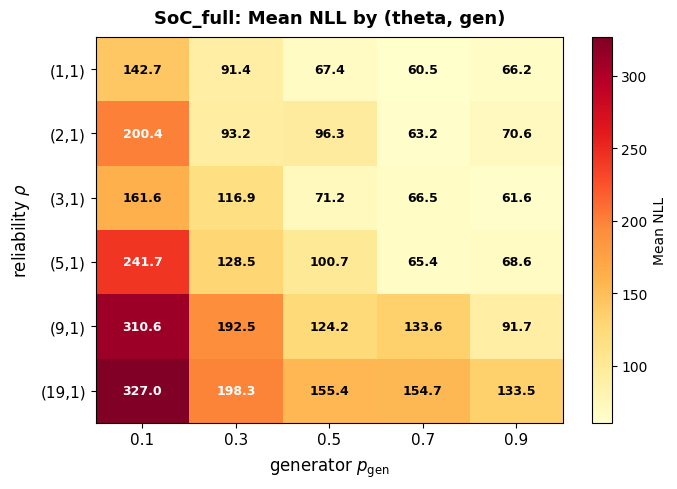

In [29]:
# ── Fit SoC_full to each child ─────────────────────────────────────────────
# SoC_full has two free parameters: theta (6 values) and gen (5 values) → 30 combinations.
# We fit every combination, then plot mean NLL as a heatmap (theta × gen grid).

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ── 1. Load SoC_full probability tables ────────────────────────────────────
soc_full_path = os.path.join(os.getcwd(), "model_runs", "SoC_full.csv")
df_full = pd.read_csv(soc_full_path)

prob_cols       = [f'P(n={k} boxes open)' for k in range(6)]
max_model_trial = int(df_full['trialNo'].max())   # 70

theta_values = list(df_full[['theta','gen','true_prior']].drop_duplicates()['theta'].unique())
gen_values   = sorted(df_full['gen'].unique())    # [0.1, 0.3, 0.5, 0.7, 0.9]

# Build lookup table keyed by (theta, gen), indexed by trialNo
model_tables_full = {
    (theta, gen): df_full[
        (df_full['theta'] == theta) & (df_full['gen'] == gen)
    ].set_index('trialNo')[prob_cols]
    for theta in theta_values
    for gen in gen_values
}

# ── 2. Compute log likelihood for each child × (theta, gen) combination ───────
# For each trial i where child has opened n_i boxes:
#   contribution = log P(n = n_i | trial i, theta, gen)
# Sum over all trials gives the total log likelihood for that child × model.

EPS = 1e-10
records_full = []

for child in children:
    row = {'child': child}
    for theta in theta_values:
        for gen in gen_values:
            table   = model_tables_full[(theta, gen)]
            log_lik = 0.0
            for trial_no, n_boxes in child_sequences[child]:
                if trial_no > max_model_trial:
                    continue
                p = float(table.loc[trial_no, f'P(n={n_boxes} boxes open)'])
                log_lik += np.log(max(p, EPS))
            row[f'theta={theta}_gen={gen}'] = round(log_lik, 3)
    records_full.append(row)

results_full_df = pd.DataFrame(records_full)
ll_cols_full = [f'theta={t}_gen={g}' for t in theta_values for g in gen_values]

# Best-fit combination per child
results_full_df['best_combo'] = results_full_df[ll_cols_full].idxmax(axis=1)
print("Best-fit SoC_full model counts across children:")
print(results_full_df['best_combo'].value_counts())

# ── 3. Build mean NLL grid (rows = theta, cols = gen) ────────────────────────
nll_full_df = -results_full_df[ll_cols_full]

grid = np.array([
    [nll_full_df[f'theta={t}_gen={g}'].mean() for g in gen_values]
    for t in theta_values
])

print("\nMean NLL grid (theta rows × gen cols):")
print(pd.DataFrame(grid, index=theta_values, columns=gen_values).round(1).to_string())

# ── 4. Heatmap: mean NLL across the (theta, gen) parameter grid ──────────────
# Lower NLL = better fit; the colormap runs light→dark so the best cell stands out.

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(grid, aspect='auto', cmap='YlOrRd', origin='upper')

# Axis labels
ax.set_xticks(range(len(gen_values)))
ax.set_xticklabels([str(g) for g in gen_values], fontsize=11)
ax.set_yticks(range(len(theta_values)))
ax.set_yticklabels(theta_values, fontsize=11)
ax.set_xlabel(r'generator $p_{\mathrm{gen}}$', fontsize=12, labelpad=6)
ax.set_ylabel(r'reliability $\rho$', fontsize=12, labelpad=6)
ax.set_title('SoC_full: Mean NLL by (theta, gen)',
             fontsize=13, fontweight='bold', pad=10)

# Annotate each cell with its value
for i in range(len(theta_values)):
    for j in range(len(gen_values)):
        val = grid[i, j]
        # use white text on dark cells, black on light cells
        text_color = 'white' if val > (grid.max() + grid.min()) / 2 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=9, color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Mean NLL')
plt.tight_layout()
plt.show()


The best combination is gen = 0.7, theta = (1,1), LL 60.5

Now, make a bar plot with 95CI that compares the loglikes of these three models we just fitted together
full, gen, and rel - demonstrating which one fits children better. Provide t-tests and d showing differnce between fits.


Model            Mean NLL       SD         95% CI
------------------------------------------------
SoC-Rel            148.40    96.75 [ 129.44,  167.37]
SoC-Gen             89.94   142.14 [  62.08,  117.80]
SoC_full            51.25    28.94 [  45.58,   56.92]

Paired t-tests (NLL; lower = better fit):
Comparison                            t          p    Cohen's d   sig
-------------------------------------------------------------------
SoC-Rel vs SoC-Gen                4.881     0.0000        0.488   ***
SoC-Gen vs SoC_full               3.067     0.0028        0.307    **
SoC-Rel vs SoC_full              12.774     0.0000        1.277   ***


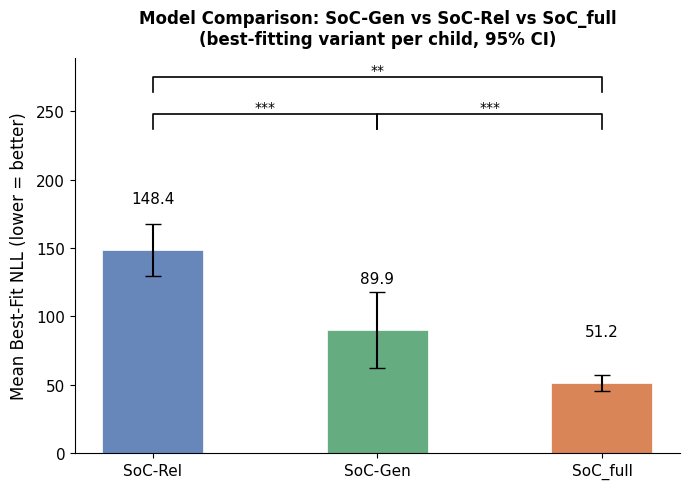

In [30]:
# ── Model comparison: SoC-Gen vs SoC-Rel vs SoC_full ───────────────────────
# For each child, take the best log-likelihood across all parameter variants of
# each model (i.e. the LL at the best-fitting parameter setting per child).
# Lower NLL = better fit. Compare with a bar plot, paired t-tests, and Cohen's d.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Best LL per child for each model ──────────────────────────────────────
# Max LL over all variants = best any parameter setting can explain that child.

best_ll = {
    'SoC-Rel':      results_rel_df[ll_cols_rel].max(axis=1).values,
    'SoC-Gen':      results_df[ll_cols].max(axis=1).values,
    'SoC_full':   results_full_df[ll_cols_full].max(axis=1).values,
}

# Convert to negative LL so that lower bar = worse fit (standard convention)
best_nll = {name: -ll for name, ll in best_ll.items()}

model_names  = list(best_nll.keys())
colors       = ['#4C72B0', '#4A9E6B', '#D4703A']   # blue (Rel), green (Gen), orange (Full)

# ── 2. Summary statistics ─────────────────────────────────────────────────────
print(f"{'Model':<14} {'Mean NLL':>10} {'SD':>8} {'95% CI':>14}")
print("-" * 48)
means, cis = [], []
for name in model_names:
    nll   = best_nll[name]
    m     = nll.mean()
    se    = nll.std(ddof=1) / np.sqrt(len(nll))
    ci    = 1.96 * se
    means.append(m)
    cis.append(ci)
    print(f"{name:<14} {m:>10.2f} {nll.std(ddof=1):>8.2f} [{m-ci:>7.2f}, {m+ci:>7.2f}]")

# ── 3. Paired t-tests and Cohen's d for every pair ───────────────────────────
# Paired because the same children are scored under each model.
# Cohen's d (paired) = mean(diff) / std(diff, ddof=1)

pairs = [
    ('SoC-Rel',    'SoC-Gen'),
    ('SoC-Gen',    'SoC_full'),
    ('SoC-Rel',    'SoC_full'),
]

print("\nPaired t-tests (NLL; lower = better fit):")
print(f"{'Comparison':<30} {'t':>8} {'p':>10} {"Cohen's d":>12} {'sig':>5}")
print("-" * 67)
for a, b in pairs:
    diff  = best_nll[a] - best_nll[b]
    t, p  = stats.ttest_rel(best_nll[a], best_nll[b])
    d     = diff.mean() / diff.std(ddof=1)
    sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{a+' vs '+b:<30} {t:>8.3f} {p:>10.4f} {d:>12.3f} {sig:>5}")

# ── 4. Bar plot with 95% CI ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(model_names))
bars = ax.bar(x, means, yerr=cis, capsize=6, width=0.45,
              color=colors, alpha=0.85, edgecolor='white', linewidth=0.6)

# Annotate bars with mean value
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(cis) * 1.15,
            f'{m:.1f}', ha='center', va='bottom', fontsize=11)

# Significance brackets
def sig_bracket(ax, x1, x2, y, label, dy=8):
    ax.plot([x1, x1, x2, x2], [y, y+dy, y+dy, y], lw=1.2, color='black')
    ax.text((x1+x2)/2, y+dy, label, ha='center', va='bottom', fontsize=10)

# place brackets above the tallest bar + annotations
bracket_base = max(m + ci for m, ci in zip(means, cis)) + max(cis) * 2.5
gap = (max(means) - min(means)) * 0.18 + 10

sig_results = {}
for a, b in pairs:
    diff = best_nll[a] - best_nll[b]
    _, p = stats.ttest_rel(best_nll[a], best_nll[b])
    sig_results[(a, b)] = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

label_pairs = [
    (0, 1, sig_results[('SoC-Rel', 'SoC-Gen')],    bracket_base),
    (1, 2, sig_results[('SoC-Rel', 'SoC_full')],  bracket_base),
    (0, 2, sig_results[('SoC-Gen', 'SoC_full')],  bracket_base + gap),
]
for x1, x2, label, y in label_pairs:
    sig_bracket(ax, x1, x2, y, label, dy=gap * 0.4)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Mean Best-Fit NLL (lower = better)', fontsize=12, labelpad=6)
ax.set_title('Model Comparison: SoC-Gen vs SoC-Rel vs SoC_full\n(best-fitting variant per child, 95% CI)',
             fontsize=12, fontweight='bold', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()


Best-fitting model counts:
  SoC-Rel: 0
  SoC-Gen: 7
  SoC_full: 93


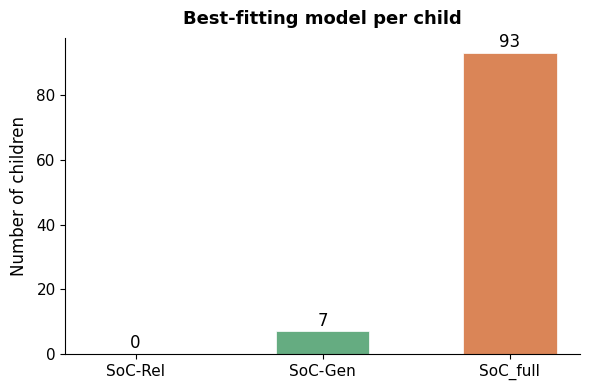

In [31]:
# Count how many children each model fits best
# Stack the per-child best-LL arrays and take argmax across models.

import numpy as np
import matplotlib.pyplot as plt

model_order  = ['SoC-Rel', 'SoC-Gen', 'SoC_full']
colors_order = ['#4C72B0', '#4A9E6B', '#D4703A']

ll_matrix = np.column_stack([best_ll[m] for m in model_order])  # shape (n_children, 3)
winner_idx = np.argmax(ll_matrix, axis=1)                        # best model index per child
counts = [np.sum(winner_idx == i) for i in range(len(model_order))]

print("Best-fitting model counts:")
for name, count in zip(model_order, counts):
    print(f"  {name}: {count}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(model_order, counts, color=colors_order, alpha=0.85,
              edgecolor='white', linewidth=0.6, width=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontsize=12)

ax.set_ylabel('Number of children', fontsize=12, labelpad=6)
ax.set_title('Best-fitting model per child', fontsize=13, fontweight='bold', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()


Model              Mean NLL       SD             95% CI
--------------------------------------------------------
SoC-Lesioned         233.62   216.73 [ 191.14,  276.10]
SoC-Rel              148.40    96.75 [ 129.44,  167.37]
SoC-Gen               89.94   142.14 [  62.08,  117.80]
SoC_full              51.25    28.94 [  45.58,   56.92]

Paired t-tests vs SoC_full (NLL; lower = better fit):
Comparison                                t          p    Cohen's d   sig
-----------------------------------------------------------------------
SoC-Lesioned vs SoC_full              9.276     0.0000        0.928   ***
SoC-Rel vs SoC_full                  12.774     0.0000        1.277   ***
SoC-Gen vs SoC_full                   3.067     0.0028        0.307    **


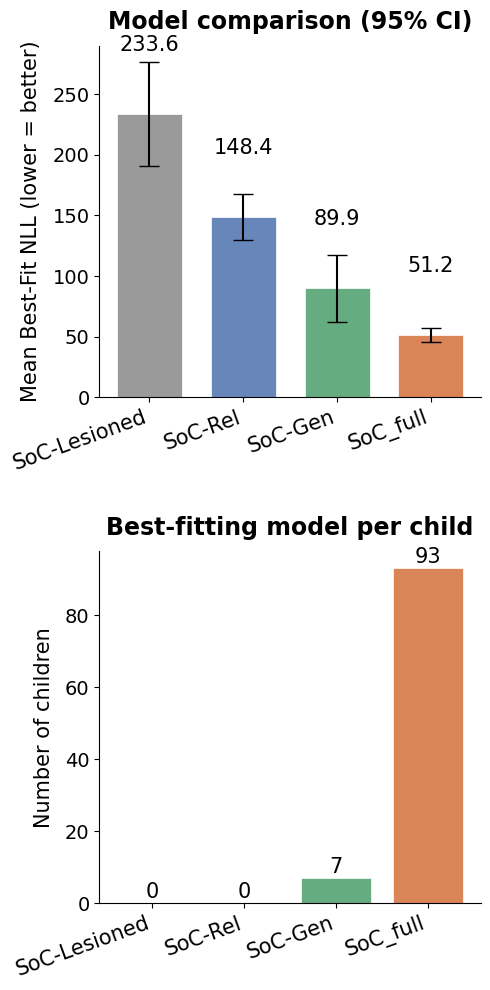

In [32]:
# ── Add SoC-Lesioned and compare all four models ─────────────────────────────
# SoC-Lesioned = SoC-Gen fixed at theta=(99,1), gen=0.1.
# No new compute needed: this is exactly results_df['gen=0.1'].

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Assemble per-child best LL for all four models ────────────────────────
# SoC-Lesioned: single fixed variant, so LL is already final (no max needed)
# The other three reuse best_ll from the comparison cell above.

best_ll_4 = {
    'SoC-Lesioned': results_df['gen=0.1'].values,
    'SoC-Rel':      best_ll['SoC-Rel'],
    'SoC-Gen':      best_ll['SoC-Gen'],
    'SoC_full':     best_ll['SoC_full'],
}

model_names_4  = list(best_ll_4.keys())
colors_4       = ['#888888', '#4C72B0', '#4A9E6B', '#D4703A']  # grey, blue, green, orange
best_nll_4     = {name: -ll for name, ll in best_ll_4.items()}

# ── 2. Summary statistics ─────────────────────────────────────────────────────
print(f"{'Model':<16} {'Mean NLL':>10} {'SD':>8} {'95% CI':>18}")
print("-" * 56)
means_4, cis_4 = [], []
for name in model_names_4:
    nll = best_nll_4[name]
    m   = nll.mean()
    ci  = 1.96 * nll.std(ddof=1) / np.sqrt(len(nll))
    means_4.append(m)
    cis_4.append(ci)
    print(f"{name:<16} {m:>10.2f} {nll.std(ddof=1):>8.2f} [{m-ci:>7.2f}, {m+ci:>7.2f}]")

# ── 3. Paired t-tests and Cohen's d vs SoC_full ────────────────────────────
print("\nPaired t-tests vs SoC_full (NLL; lower = better fit):")
print(f"{'Comparison':<34} {'t':>8} {'p':>10} {"Cohen's d":>12} {'sig':>5}")
print("-" * 71)
comparisons = [(name, 'SoC_full') for name in model_names_4 if name != 'SoC_full']
for a, b in comparisons:
    diff = best_nll_4[a] - best_nll_4[b]
    t, p = stats.ttest_rel(best_nll_4[a], best_nll_4[b])
    d    = diff.mean() / diff.std(ddof=1)
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{a+' vs '+b:<34} {t:>8.3f} {p:>10.4f} {d:>12.3f} {sig:>5}")

# ── 4. Two stacked plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(5, 10))
x = np.arange(len(model_names_4)) * 0.65

# — Top: mean NLL bar plot —
ax = axes[0]
bars = ax.bar(x, means_4, yerr=cis_4, capsize=7, width=0.45,
              color=colors_4, alpha=0.85, edgecolor='white', linewidth=0.6)
for bar, m in zip(bars, means_4):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(cis_4) * 1.15,
            f'{m:.1f}', ha='center', va='bottom', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(model_names_4, fontsize=15, rotation=20, ha='right')
ax.set_ylabel('Mean Best-Fit NLL (lower = better)', fontsize=15, labelpad=8)
ax.set_title('Model comparison (95% CI)', fontsize=17, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=14)
ax.spines[['top', 'right']].set_visible(False)

# — Bottom: winner counts —
ll_matrix  = np.column_stack([best_ll_4[m] for m in model_names_4])
winner_idx = np.argmax(ll_matrix, axis=1)
counts_4   = [np.sum(winner_idx == i) for i in range(len(model_names_4))]

ax2 = axes[1]
bars2 = ax2.bar(x, counts_4, color=colors_4, alpha=0.85,
                edgecolor='white', linewidth=0.6, width=0.5)
for bar, count in zip(bars2, counts_4):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.4,
             str(count), ha='center', va='bottom', fontsize=15)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names_4, fontsize=15, rotation=20, ha='right')
ax2.set_ylabel('Number of children', fontsize=15, labelpad=8)
ax2.set_title('Best-fitting model per child', fontsize=17, fontweight='bold', pad=12)
ax2.tick_params(axis='y', labelsize=14)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout(h_pad=3)
plt.show()


In [33]:
# ── Best-fitting parameters per child for each model variant ─────────────────
# SoC-Gen:     one free parameter → best gen value
# SoC-Rel:     one free parameter → best theta value
# SoC_full:    two free parameters → best (theta, gen) combination
# SoC-Lesioned: no free parameters (fixed gen=0.1, theta=(99,1))

import pandas as pd

# Parse SoC_full best_combo string "theta=(X,X)_gen=Y" into separate columns
def parse_combo(s):
    # format: "theta=(X,X)_gen=Y"
    theta_part, gen_part = s.split('_gen=')
    theta = theta_part.replace('theta=', '')
    return theta, gen_part

theta_best, gen_best = zip(*results_full_df['best_combo'].map(parse_combo))

params_table = pd.DataFrame({
    'child':               results_df['child'],
    'SoC-Rel (theta)':     results_rel_df['best_theta'].values,
    'SoC-Gen (gen)':       results_df['best_gen'].values,
    'SoC_full (theta)':    list(theta_best),
    'SoC_full (gen)':      list(gen_best),
})

print(params_table.to_string(index=False))

# Summary: distribution of best-fit values per model
print("\n--- SoC-Rel: best theta distribution ---")
print(results_rel_df['best_theta'].value_counts().sort_index().to_string())

print("\n--- SoC-Gen: best gen distribution ---")
print(results_df['best_gen'].value_counts().sort_index().to_string())

print("\n--- SoC_full: best (theta, gen) distribution ---")
combo_counts = pd.Series(list(zip(theta_best, gen_best))).value_counts().sort_index()
for (theta, gen), count in combo_counts.items():
    print(f"  theta={theta}, gen={gen}: {count}")


child SoC-Rel (theta) SoC-Gen (gen) SoC_full (theta) SoC_full (gen)
 D001           (3,1)           0.3            (5,1)            0.3
 D002           (3,1)           0.5            (2,1)            0.7
 D003           (3,1)           0.9            (2,1)            0.5
 D004           (1,1)           0.9            (1,1)            0.9
 D005           (1,1)           0.7            (9,1)            0.7
 D006           (9,1)           0.5            (2,1)            0.5
 D007           (1,1)           0.9           (19,1)            0.9
 D008           (1,1)           0.9            (9,1)            0.9
 D009           (9,1)           0.9            (3,1)            0.7
 D010           (5,1)           0.9            (2,1)            0.5
 D011           (5,1)           0.9            (1,1)            0.9
 D012           (5,1)           0.9            (9,1)            0.9
 D013           (3,1)           0.5            (1,1)            0.5
 D014           (2,1)           0.9            (

/var/folders/3z/615sjdb5051640fr7dmdx05m0000gn/T/ipykernel_3264/4013884535.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


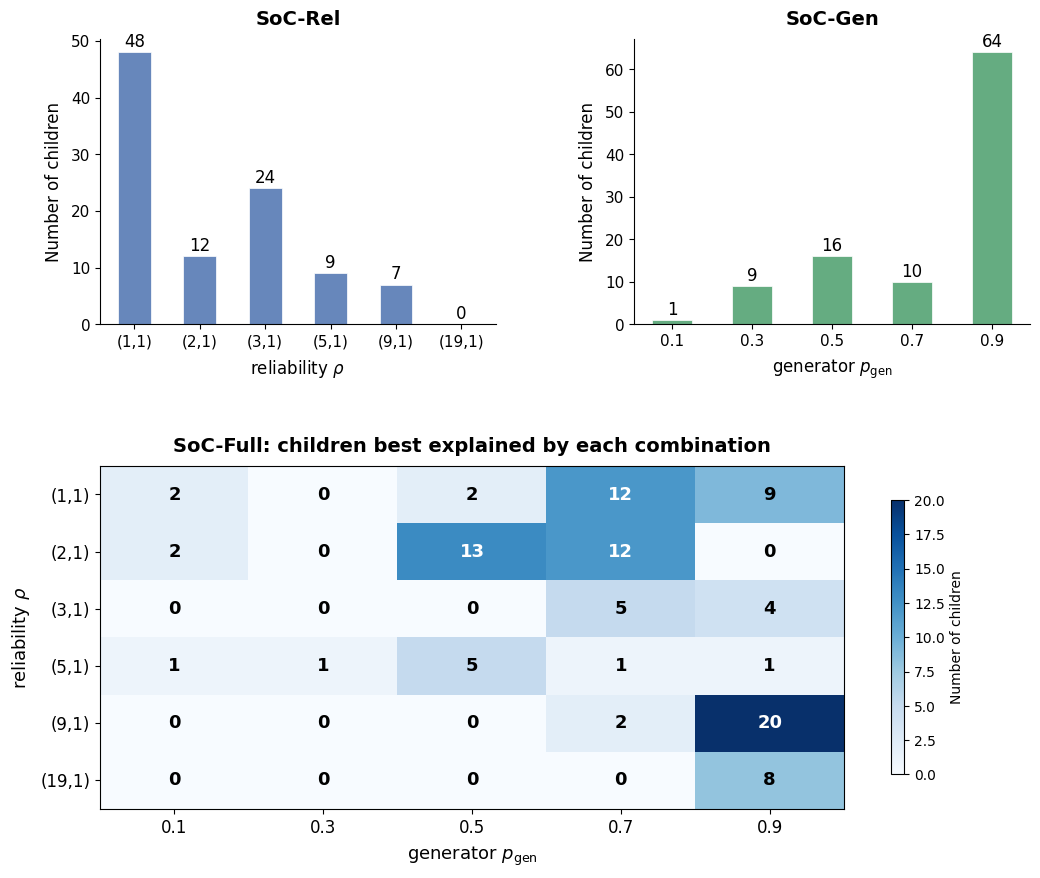

In [34]:
# ── Count plots: children best explained by each model variant ───────────────
# Top row: SoC-Rel (bar, by theta) and SoC-Gen (bar, by gen)
# Bottom:  SoC-Full (heatmap, theta × gen grid)

import numpy as np
import matplotlib.pyplot as plt

# ── SoC-Rel counts ────────────────────────────────────────────────────────────
rel_counts = results_rel_df['best_theta'].value_counts()
rel_counts = [rel_counts.get(str(t), 0) for t in theta_values]   # ordered by theta_values

# ── SoC-Gen counts ────────────────────────────────────────────────────────────
# gen_values defined in soc_gen_fitting cell (same variable reused by soc_full_fitting)
gen_values_gen = sorted(results_df[[c for c in results_df.columns if c.startswith('gen=')]].columns
                        .str.replace('gen=','').astype(float))
gen_counts = results_df['best_gen'].astype(float).value_counts()
gen_counts = [int(gen_counts.get(g, 0)) for g in gen_values_gen]

# ── SoC-Full counts: build theta × gen grid ───────────────────────────────────
def parse_combo(s):
    theta_part, gen_part = s.split('_gen=')
    return theta_part.replace('theta=', ''), float(gen_part)

combos = results_full_df['best_combo'].map(parse_combo)
full_theta_vals = theta_values          # from soc_full_fitting
full_gen_vals   = sorted(df_full['gen'].unique())

count_grid = np.zeros((len(full_theta_vals), len(full_gen_vals)), dtype=int)
for theta, gen in combos:
    i = full_theta_vals.index(theta)
    j = full_gen_vals.index(gen)
    count_grid[i, j] += 1

# ── Figure layout: 2 bar plots on top, heatmap below ─────────────────────────
fig = plt.figure(figsize=(12, 10))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.45, wspace=0.35)

ax_rel  = fig.add_subplot(gs[0, 0])
ax_gen  = fig.add_subplot(gs[0, 1])
ax_heat = fig.add_subplot(gs[1, :])

# — SoC-Rel bar plot —
x_rel = np.arange(len(theta_values))
bars = ax_rel.bar(x_rel, rel_counts, color='#4C72B0', alpha=0.85,
                  edgecolor='white', linewidth=0.6, width=0.5)
for bar, count in zip(bars, rel_counts):
    ax_rel.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(count), ha='center', va='bottom', fontsize=12)
ax_rel.set_xticks(x_rel)
ax_rel.set_xticklabels(theta_values, fontsize=11)
ax_rel.set_xlabel(r'reliability $\rho$', fontsize=12, labelpad=6)
ax_rel.set_ylabel('Number of children', fontsize=12, labelpad=6)
ax_rel.set_title('SoC-Rel', fontsize=14, fontweight='bold', pad=10)
ax_rel.spines[['top', 'right']].set_visible(False)
ax_rel.tick_params(axis='y', labelsize=11)

# — SoC-Gen bar plot —
x_gen = np.arange(len(gen_values_gen))
bars2 = ax_gen.bar(x_gen, gen_counts, color='#4A9E6B', alpha=0.85,
                   edgecolor='white', linewidth=0.6, width=0.5)
for bar, count in zip(bars2, gen_counts):
    ax_gen.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(count), ha='center', va='bottom', fontsize=12)
ax_gen.set_xticks(x_gen)
ax_gen.set_xticklabels([str(g) for g in gen_values_gen], fontsize=11)
ax_gen.set_xlabel(r'generator $p_{\mathrm{gen}}$', fontsize=12, labelpad=6)
ax_gen.set_ylabel('Number of children', fontsize=12, labelpad=6)
ax_gen.set_title('SoC-Gen', fontsize=14, fontweight='bold', pad=10)
ax_gen.spines[['top', 'right']].set_visible(False)
ax_gen.tick_params(axis='y', labelsize=11)

# — SoC-Full heatmap —
im = ax_heat.imshow(count_grid, aspect='auto', cmap='Blues', origin='upper')
ax_heat.set_xticks(range(len(full_gen_vals)))
ax_heat.set_xticklabels([str(g) for g in full_gen_vals], fontsize=12)
ax_heat.set_yticks(range(len(full_theta_vals)))
ax_heat.set_yticklabels(full_theta_vals, fontsize=12)
ax_heat.set_xlabel(r'generator $p_{\mathrm{gen}}$', fontsize=13, labelpad=6)
ax_heat.set_ylabel(r'reliability $\rho$', fontsize=13, labelpad=6)
ax_heat.set_title('SoC-Full: children best explained by each combination',
                  fontsize=14, fontweight='bold', pad=10)

# Annotate each cell
for i in range(len(full_theta_vals)):
    for j in range(len(full_gen_vals)):
        val = count_grid[i, j]
        text_color = 'white' if val > count_grid.max() / 2 else 'black'
        ax_heat.text(j, i, str(val), ha='center', va='center',
                     fontsize=13, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax_heat, label='Number of children', shrink=0.8)
plt.tight_layout()
plt.show()
